# Robbins-Monro 算法

> Robbins-Monro **(RM)** 算法与随机梯度下降 **(SGD)** 都是在只能获取含噪声观测的情况下进行迭代求解的算法，两者的求解目标不同：
>
> ---

| 算法 | 求解目标 | 本质任务 |
|---|---|---|
| RM | $g(w) = 0$ | **求根**：找使方程为零的 $w^*$ |
| SGD | $g'(w) = 0$ | **求极值**：找使导数为零的 $w^*$（等价于最小化损失函数 $g(w)$）|

> ---
>
> **关系**：SGD 是 RM 的特例。将损失函数的梯度 $g'(w)$ 视为 RM 中的 $g(w)$，令其等于零即可得到 SGD。因此，RM 算法是比 SGD 更基础、更一般的理论框架。

> **RM 算法收敛的三大条件**：
>
> 1. **梯度有界**：$g(w)$ 的梯度在全局范围内有上下界，即 $g'(w)$ 有界
> 2. **步长条件**：步长 $a_k$ 衰减不能太快也不能太慢，须满足 $\sum_{k=1}^\infty a_k = \infty$ 且 $\sum_{k=1}^\infty a_k^2 < \infty$（收敛性介于调和级数与平方 $p$ 级数之间），典型选取 $a_k = 1/k$
> 3. **噪声条件**：噪声期望为零 $E[\eta_k] = 0$（无偏），且方差有界 $\text{Var}(\eta_k) < \infty$（若期望不为零则必然引入系统偏差）

> **RM 算法的推导起点是增量均值估计公式**。均值估计的迭代式为：
>
> $$w_{k+1} = w_k - \frac{1}{k}(w_k - x_k)$$
>
> 其中 $x_k$ 是第 $k$ 个采样观测，$\frac{1}{k}$ 是步长。
> 之所以可以将 $w_k - x_k$ 视为含噪声的函数观测 $\tilde{g}(w_k, \eta_k)$，
> 是因为均值估计的目标等价于求解方程 $g(w) = w - E[X] = 0$，对其进行分解：
>
> $$w_k - x_k = \underbrace{(w_k - E[X])}_{g(w_k)} + \underbrace{(E[X] - x_k)}_{\eta_k}$$
>
> 即 $\tilde{g}(w_k, \eta_k) = g(w_k) + \eta_k$，其中噪声 $\eta_k = E[X] - x_k$ 满足：
> - **零均值**：$E[\eta_k] = E[E[X] - x_k] = 0$
> - **方差有界**：$\text{Var}(\eta_k) = \text{Var}(x_k) < \infty$
>
> 三个 RM 收敛条件均满足，因此**增量均值估计是 RM 算法的一个特例**。
> 与后续示例一（$g(w) = w - 10$）的对比如下：
>
> ---

| | 均值估计（RM 有噪声实例） | 示例一（RM 无噪声退化） |
|---|---|---|
| 目标方程 $g(w)=0$ | $w - E[X] = 0$ | $w - 10 = 0$ |
| 真实值 | $E[X]$（**未知**，只能采样） | $10$（**已知**，可直接计算） |
| 含噪声观测 $\tilde{g}$ | $w_k - x_k = g(w_k) + \eta_k$ | $w_k - 10 = g(w_k)$，噪声 $\eta_k = 0$ |
| 迭代公式 | $w_{k+1} = w_k - \dfrac{1}{k}(w_k - x_k)$ | $w_{k+1} = w_k - 0.5(w_k - 10)$ |

> ---
>
> 示例一是 RM 在函数值**精确已知**时的退化情形（$\eta_k \equiv 0$）；
> 均值估计则是 RM 在只能获取**含噪声样本**时的典型应用。
> 分解公式正是为了解释：用 $x_k$ 替代未知的 $E[X]$ 仍然合法，
> 因为替换引入的误差 $\eta_k$ 满足 RM 的噪声条件。

## 一、均值估计（Mean Estimation）

### 1.1 定义式

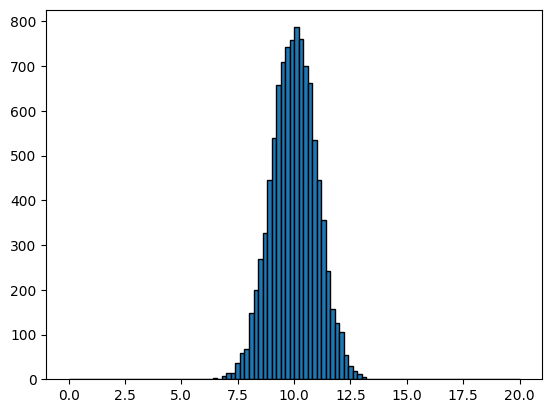

In [1]:
# 导入 NumPy 库，用于数值计算（生成随机数、数组运算等）
import numpy as np
# 导入 Matplotlib 绘图库，用于可视化随机变量分布
import matplotlib.pyplot as plt


def f(x):
    '''
    目标函数 f(x) = x³ - 5
    用于验证 RM 算法：当 f(w*) = 0 时，w* = ∛5 ≈ 1.7100

    参数:
        x (float 或 np.ndarray): 输入值，可为标量或任意形状数组

    返回值:
        float 或 np.ndarray: f(x) 的计算结果，形状与输入 x 相同
    '''
    return x**3 - 5  # 三次函数值：x 的三次方减 5


# 从均值=10、标准差=1 的正态分布中随机采样 10000 个点
# 返回值：shape (10000,) 的一维数组，每个元素代表一个随机样本 x_i
x = np.random.normal(10, 1, 10000)  # 参数：均值=10, 标准差=1, 样本数量=10000

# 绘制样本直方图，直观展示 X ~ N(10,1) 的概率分布形态
plt.hist(x, bins=100, range=(0, 20), edgecolor='black')  # bins=100：分100组；range=(0,20)：显示区间
plt.show()  # 渲染并显示图形

In [2]:
# 方法一（定义式）：直接计算 f(x) 所有样本值的算术平均
# 等价于用大数定律近似估计 E[f(X)] = E[X³-5]
# 返回值：标量 float，即 10000 个样本 f(x_i) 的均值
f(x).mean()

np.float64(1022.1271327734455)

### 1.2 迭代式

迭代公式推导：

$$w_{k+1} = w_k - \frac{1}{k}(w_k - x_k)$$

等价于逐步加入新样本并更新估计，步长 $a_k=1/k$ 满足 RM 收敛条件。

In [3]:
# 方法二（迭代式）：步长 a_k = 1/k（调和级数步长，满足 RM 条件）
# 初始化 w₁ = 0
w = 0
# 按公式 w_{k+1} = w_k - (1/k)*(w_k - f(x_{k-1})) 迭代更新
# 步长 1/k 满足 RM 条件：∑(1/k)=∞（不衰减太快）且 ∑(1/k²)<∞（不衰减太慢）
for k in range(1, 10000):  # k 从 1 到 9999，共 9999 次迭代
    # 注意：x 数组下标从 0 开始，第 k 个样本对应索引 k-1
    # w_k - f(x_{k-1}) 是当前估计与样本函数值的偏差
    w = w - 1/k * (w - f(x[k-1]))  # 按 RM 公式更新 w
print(w)  # 打印最终收敛值，应接近 E[X³-5] ≈ 1030

1022.1404572322118


In [4]:
# 方法二变体：步长 a_k = 1/(k+20)（加常数偏移，收敛稍慢但仍满足 RM 条件）
w = 0  # 初始化 w₁ = 0
for k in range(1, 10000):  # k 从 1 到 9999，共 9999 次迭代
    # 步长 1/(k+20) 略小于 1/k，同样满足调和级数条件
    w = w - 1/(k+20) * (w - f(x[k-1]))  # 按 RM 公式更新 w
print(w)  # 最终收敛值，稍慢于 1/k 步长，但最终仍收敛到 E[X³-5]

1020.1000530856287


In [5]:
# 方法二变体：步长 a = 1/1000（常数步长，严格意义上不满足 RM 条件）
# 常数步长使 ∑a_k² 发散，理论上不保证收敛，但实际采样量足够时仍可近似收敛
w = 0  # 初始化 w₁ = 0
for k in range(1, 10000):  # k 从 1 到 9999，共 9999 次迭代
    w = w - 1/1000 * (w - f(x[k-1]))  # 使用固定步长 0.001
print(w)  # 最终估计值，存在一定系统偏差，但仍接近真实期望

1037.2053696946236


## 二、Robbins-Monro 算法

> RM 算法的一般形式：
>
> $$w_{k+1} = w_k - a_k \tilde{g}(w_k, \eta_k), \quad k=1,2,3\ldots$$
>
> 各参数含义如下：
>
> ---

| 符号 | 含义 |
|---|---|
| $w_k$ | 第 $k$ 次迭代的当前估计值（待求方程根 $w^*$ 的近似） |
| $w_{k+1}$ | 经本次更新后得到的新估计值 |
| $a_k$ | 第 $k$ 步的**步长**（学习率），控制每次更新的幅度，须满足 RM 收敛条件：$\sum_{k=1}^\infty a_k = \infty$（步长不能衰减太快）且 $\sum_{k=1}^\infty a_k^2 < \infty$（步长不能衰减太慢），典型选取 $a_k = 1/k$ |
| $\tilde{g}(w_k,\eta_k)$ | 对真实函数 $g(w_k)$ 的**含噪声观测**，即 $\tilde{g}(w_k,\eta_k) = g(w_k) + \eta_k$，无需知道 $g$ 的解析形式，只需能采样观测 |
| $g(w)$ | 待求解的目标方程，算法目标是找到使 $g(w^*)=0$ 的根 $w^*$ |
| $\eta_k$ | 第 $k$ 步引入的**随机噪声**，需满足：期望为零 $E[\eta_k]=0$（无偏）、方差有界 $\text{Var}(\eta_k) < \infty$ |

> ---
>
> 通过含噪声的观测 $\tilde{g}$ 求解方程 $g(w)=0$，无需知道 $g$ 的解析形式。

### 2.1 示例一：$f(x) = x - 10$

方程根 $w^* = 10$（梯度为常数 1，全局有界，满足 RM 第一条件）

In [ ]:
# 定义方程 f(x) = x - 10，求解 f(w*) = 0 即 w* = 10
# 该函数梯度为常数 1（全局有界），满足 RM 算法第一收敛条件
f = lambda x: x - 10

# 初始值 w = 1000，距真实解 w*=10 很远，验证 RM 远端收敛能力
w = 1000
# 固定步长 a = 0.5：因 f 梯度有界（等于1），常数步长也可保证收敛
a = 0.5
tmp = []  # 存储每步迭代结果，用于观察收敛轨迹
for i in range(65535):  # 最多迭代 65535 次
    # RM 迭代：w_{k+1} = w_k - a * f(w_k)（无噪声版本）
    w = w - a * f(w)  # 每步向 w*=10 靠近
    tmp.append(w)     # 记录当前迭代值
print(w)          # 最终收敛值，应精确等于 10
print(tmp[:20])   # 打印前 20 步，观察指数级快速收敛过程

10.0
[505.0, 257.5, 133.75, 71.875, 40.9375, 25.46875, 17.734375, 13.8671875, 11.93359375, 10.966796875, 10.4833984375, 10.24169921875, 10.120849609375, 10.0604248046875, 10.03021240234375, 10.015106201171875, 10.007553100585938, 10.003776550292969, 10.001888275146484, 10.000944137573242]


### 2.2 示例二：$f(x) = x^3 - 5$

方程根 $w^* = \sqrt[3]{5} \approx 1.710$（梯度为 $3x^2$，无上界，对初始值敏感）

In [ ]:
# 定义方程 f(x) = x³ - 5，求解 f(w*) = 0 即 w* = ∛5 ≈ 1.7100
# 注意：该函数梯度为 3x²，当 x 较大时梯度无上界
# 不满足 RM 第一条件（梯度有界），因此对初始值极其敏感
f = lambda x: x**3 - 5

# 初始值必须取在真实解附近，否则梯度过大导致发散（梯度爆炸）
w = 1.7   # 初始值接近 w* ≈ 1.710
tmp = []  # 存储每步迭代值
for i in range(65535):  # 最多迭代 65535 次
    # 步长 a_k = 1/(i+1)，满足 RM 的调和级数条件（递减步长）
    w = w - 1/(i+1) * f(w)  # RM 迭代（递减步长）
    tmp.append(w)            # 记录当前值
print(w)          # 最终收敛值，应约为 1.7100（即 ∛5）
print(tmp[:20])   # 打印前 20 步，观察振荡并逐渐收敛的过程

1.7099759466766962
[1.7870000000000006, 1.4337247984999977, 2.118019100824119, 0.9926580786105648, 1.7970309683099193, 1.6631662037090005, 1.7202347282382884, 1.7089182851913267, 1.7099485213505834, 1.7099725786067483, 1.7099752645004416, 1.7099757631741106, 1.7099758869967476, 1.7099759243907242, 1.70997593742364, 1.7099759424966594, 1.7099759446535718, 1.709975945639514, 1.709975946118368, 1.7099759463632525]


In [ ]:
# 验证：1.7³ 的值应接近 5，确认 w* ≈ 1.7 是方程 x³=5 的近似解
# 返回值：标量 float，即 1.7 的三次方（约为 4.913，接近但不等于 5）
1.7**3

4.912999999999999

### 2.3 示例三：$f(x) = \arctan(x-1)$

方程根 $w^* = 1$（梯度为 $1/(1+(x-1)^2)$，全局有界，满足 RM 第一条件）

In [ ]:
# 预测试：验证 arctan(0) = 0，即 f(1) = arctan(1-1) = 0
# 确认 w* = 1 是方程 arctan(w-1)=0 的根
# 注意：本 cell 在 import math 之前执行会报 NameError，需先运行下一 cell
math.atan(0)  # arctan(0) = 0.0

0.0

In [ ]:
# 导入 Python 标准数学库，提供 atan（反正切）等数学函数
import math

# 定义方程 f(x) = arctan(x-1)，求解 f(w*) = 0 即 w* = 1
# arctan 函数值域 (-π/2, π/2)，梯度为 1/(1+(x-1)²) 全局有界（满足 RM 第一条件）
f = lambda x: math.atan(x - 1)

# 设置较大初始值 w=100，验证在远离真实解时算法的收敛能力
# arctan 梯度有界，理论上可以从任意初始值收敛，但需要足够多迭代次数
w = 100
tmp = []  # 存储每步迭代值，用于分析收敛速度
for i in range(655300):  # 迭代 655300 次（步长小，需更多次才能收敛）
    # 使用固定步长 a = 1/1000
    # 虽不严格满足 RM 步长条件，但 arctan 梯度有界时实际仍可收敛
    w = w - 1/1000 * f(w)  # RM 迭代：w 向使 f(w)→0 的方向缓慢移动
    tmp.append(w)           # 记录当前迭代值
print(w)          # 最终收敛值，应接近 1.0
print(tmp[:20])   # 打印前 20 步，观察从 100 开始缓慢下降的过程

1.000000000000111
[99.9984393043398, 99.99687860883881, 99.99531791349706, 99.99375721831454, 99.99219652329126, 99.99063582842722, 99.98907513372242, 99.98751443917689, 99.98595374479062, 99.98439305056361, 99.98283235649588, 99.98127166258742, 99.97971096883823, 99.97815027524834, 99.97658958181773, 99.97502888854642, 99.9734681954344, 99.9719075024817, 99.9703468096883, 99.96878611705421]
